In [1]:
from langchain_community.tools import DuckDuckGoSearchRun, tool

# Intiate langchain tool from tools library
web_search = DuckDuckGoSearchRun() 

# The function name, type hints, and docstring are all part of the tool
# schema that's passed to the model. Defining good, descriptive schemas
# is an extension of prompt engineering and is an important part of
# getting models to perform well.

# Convert each function to tool, so that it would be used in the same of langchain tools
@tool
def add(a: int, b: int) -> int:
    """Add two integers.

    Args:
        a: First integer
        b: Second integer
    """
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers.

    Args:
        a: First integer
        b: Second integer
    """
    return a * b
    
@tool
def calculator(query):
    """ Evaluate the given expression"""
    return eval(query)


In [2]:
from langchain_openai import ChatOpenAI

tools = [web_search,calculator, add, multiply]

# Create a llm using any model, i used chatgpt model as i have credits available on my account and api key set as an environment variable
llm =ChatOpenAI(model="gpt-4o-mini",max_tokens=150)

llm_with_tools = llm.bind_tools(tools)

In [5]:
def chatbot(state: State) -> State:
    result = llm_with_tools.invoke(state["messages"])
    return {"messages": result}

In [4]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list,add_messages]

In [23]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# Building a state graph for application
graph_builder = StateGraph(State)

# create a node for chatbot
graph_builder.add_node("chatbot",chatbot)

#create another node for tools(Node is nothing but a function/logic)
graph_builder.add_node("tools",ToolNode(tools))

# define a grapth how it should execute
# start -> chatbot -> tools condition -> chatbot

graph_builder.add_edge(START,"chatbot")
graph_builder.add_conditional_edges("chatbot",tools_condition)
graph_builder.add_edge("tools","chatbot")

# Trying to save/checkpoint the inputs/outputs
chat_app =  graph_builder.compile(checkpointer=MemorySaver())

In [24]:
from IPython.display import Image, display

def show_graph(graph):
    display(Image(graph.get_graph().draw_mermaid_png()))

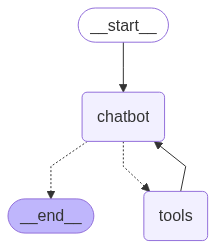

In [25]:
show_graph(chat_app)

In [22]:
from langchain_core.messages import HumanMessage
from langsmith import trace


# thread id is required when checkpoint is enabled
# It's just a name for batch out llm calls requested to track all under one thread
def answer_your_query(thread_id,query):
    
    # it's required for checkpoint
    config = {"configurable": {"thread_id": str(thread_id)}}
    
    # --- Use trace to log run ---
    with trace(
        name="tracing_app",                     # app/run name
        project_name="first_project",         # project grouping in LangSmith
        inputs={"query": query},   # log inputs
        tags=["langgraph", "tool calls"],        # optional: searchable tags
        metadata={"thread_id":thread_id}
    ) as run:
        result = chat_app.invoke({"messages":[HumanMessage(query)]},config)
        run.end(outputs={"output": result })

    

In [13]:
user_question_1 = "what is the ouput of 14 * 10 ?"
user_question_2 = "what is the ouput of 14 + 10 ?"
# user_question_3 = "Who is the president of india as on August 2025 ?"

thread_id = "User_Query"
answer_your_query(thread_id, user_question_1) 
answer_your_query(thread_id, user_question_2) 
# answer_your_query(thread_id, user_question_3) 


In [40]:
question_2_output

{'messages': [HumanMessage(content='what is the ouput of 14 * 10 ?', additional_kwargs={}, response_metadata={}, id='f6e3a1d4-a190-4a6f-ad4f-e56ff418970e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_ZjcdZ3yyoYFM56AODVWkvnSg', 'function': {'arguments': '{"a":14,"b":10}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 121, 'total_tokens': 138, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_51db84afab', 'id': 'chatcmpl-C6XcnpuEPNCcAnSO4i8bZCnBXdUPf', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--169efdaf-c3a7-4413-87de-877874e7a23f-0', tool_calls=[{'name': 'multiply', 'args': {'a': 14, 'b': 10}, 'id': 'call_Zjc

In [48]:
question_3_output

{'messages': [HumanMessage(content='what is the ouput of 14 * 10 ?', additional_kwargs={}, response_metadata={}, id='67d60ed2-3b1e-42b7-bec6-472cacbff7ca'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_XkpLgzmt7eEWt6wqX7UGmrNn', 'function': {'arguments': '{"a":14,"b":10}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 171, 'total_tokens': 188, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-C6XoO0m08v6nXumC1YQsrhopwB3Er', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--ee2260cf-ef95-414b-a009-9f1f17b1818f-0', tool_calls=[{'name': 'multiply', 'args': {'a': 14, 'b': 10}, 'id': 'call_Xkp